<a href="https://colab.research.google.com/github/Rendhazuper/PCVK_Genap_2025/blob/main/week5_26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
from google.colab import drive
drive.mount ('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob

<BarContainer object of 256 artists>

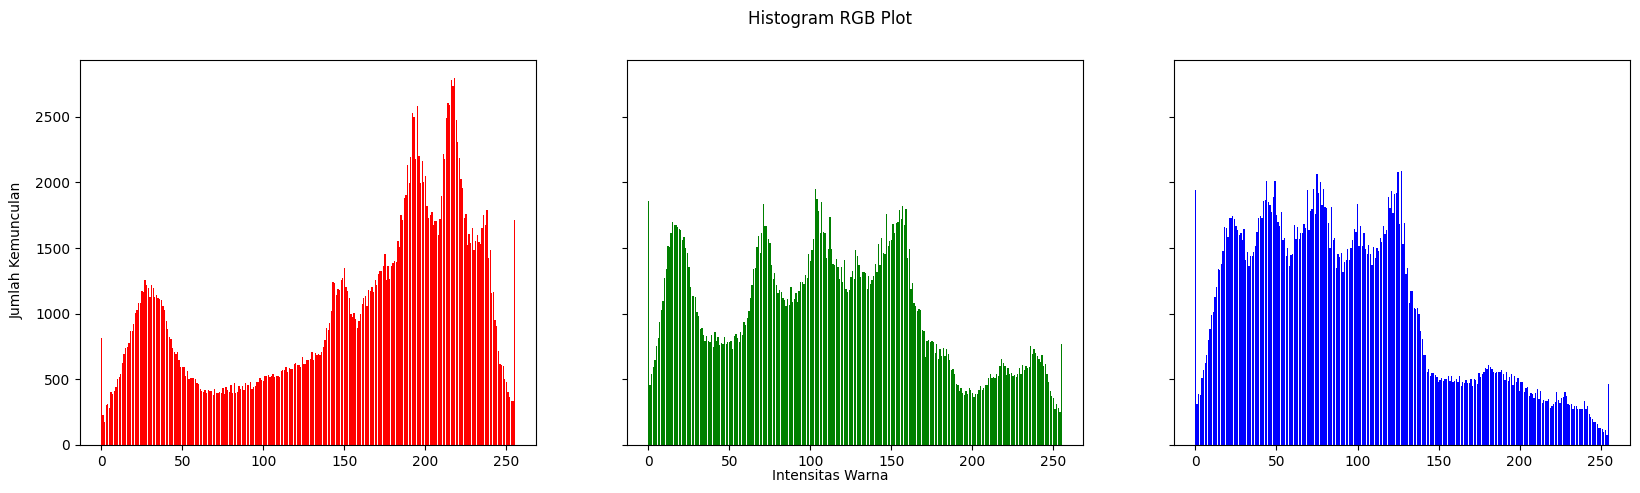

In [19]:
img = cv.imread('/content/drive/MyDrive/PCVK/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0, height):
  for x in range(0, width):
    red[img[y][x][0]] += 1
    green[img[y][x][1]] += 1
    blue[img[y][x][2]] += 1

names = np.arange(256)
fig, axs = plt.subplots(1,3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB Plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5,0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')

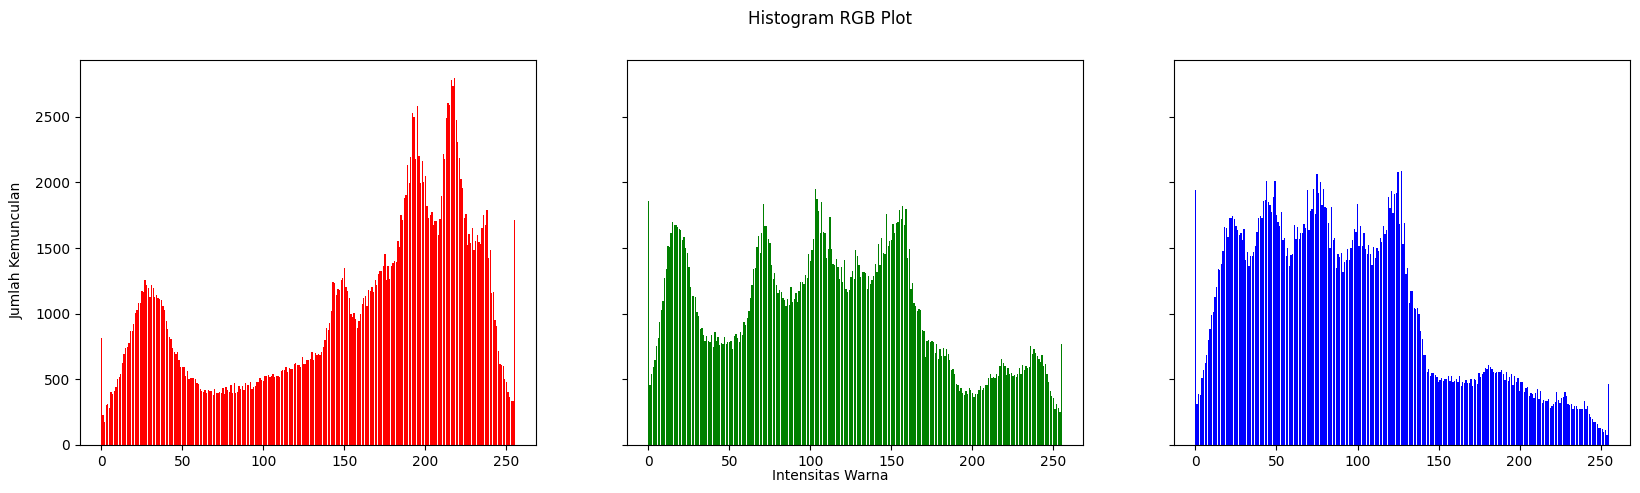

In [14]:
img = cv.imread('/content/drive/MyDrive/PCVK/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)

red, bins = np.histogram(img[:,:,0].ravel(), bins=256, range=[0,256])
green, bins = np.histogram(img[:,:,1].ravel(), bins=256, range=[0,256])
blue, bins = np.histogram(img[:,:,2].ravel(), bins=256, range=[0,256])

names = np.arange(256)
fig, axs = plt.subplots(1,3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB Plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5,0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')
plt.show()

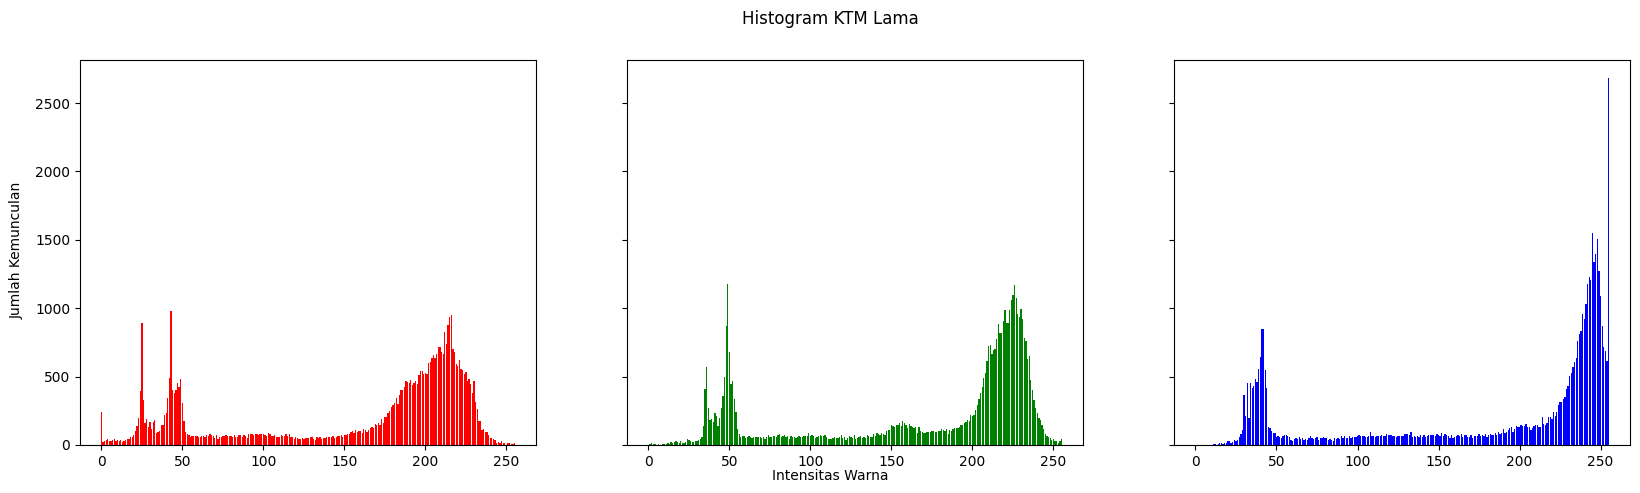

In [20]:
img = cv.imread('/content/drive/MyDrive/PCVK/images.jpeg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)


red, bins = np.histogram(img[:,:,0].ravel(), bins=256, range=[0,256])
green, bins = np.histogram(img[:,:,1].ravel(), bins=256, range=[0,256])
blue, bins = np.histogram(img[:,:,2].ravel(), bins=256, range=[0,256])

names = np.arange(256)
fig, axs = plt.subplots(1,3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram KTM Lama')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5,0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')
plt.show()

In [38]:
lenalc = cv.cvtColor(cv.imread('/content/drive/MyDrive/PCVK/lena_lc.jpg'), cv.COLOR_BGR2RGB)

r, g, b = lenalc[:,:,0], lenalc[:,:,1], lenalc[:,:,2]

histr, binsr = np.histogram(r.flatten(), 256, [0,256])
histg, binsg = np.histogram(g.flatten(), 256, [0,256])
histb, binsb = np.histogram(b.flatten(), 256, [0,256])

def manual_hist_equalization(channel):
    # 2. Hitung histogram (256 bin)
    hist, bins = np.histogram(channel.flatten(), 256, [0,256])

    # 3. Hitung CDF (kumulatif)
    cdf = hist.cumsum()

    # 4. Normalisasi CDF ke rentang 0-255
    cdf_normalized = ((cdf - cdf.min()) * 255) / (cdf.max() - cdf.min())
    cdf_normalized = cdf_normalized.astype('uint8')

    # 5. Mapping nilai lama ke nilai baru
    img_eq = cdf_normalized[channel]

    return img_eq, hist, cdf_normalized

# Proses equalization masing-masing channel
r_eq, hist_r, cdf_r = manual_hist_equalization(r)
g_eq, hist_g, cdf_g = manual_hist_equalization(g)
b_eq, hist_b, cdf_b = manual_hist_equalization(b)

# Gabungkan kembali ke RGB
img_eq = cv.merge((r_eq, g_eq, b_eq))

# Tampilkan citra sebelum & sesudah
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(lenalc)
plt.title("Citra Asli")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(img_eq)
plt.title("Citra Hasil Histogram Equalization")
plt.axis('off')
plt.show()

# Tampilkan histogram sebelum dan sesudah
def plot_histograms(original_channel, equalized_channel, color):
    hist_orig, _ = np.histogram(original_channel.flatten(), 256, [0,256])
    hist_eq, _ = np.histogram(equalized_channel.flatten(), 256, [0,256])
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.bar(range(256), hist_orig, color=color, width=1)
    plt.title(f'Histogram {color.upper()} Original')
    plt.xlim([0,256])
    plt.subplot(1,2,2)
    plt.bar(range(256), hist_eq, color=color, width=1)
    plt.title(f'Histogram {color.upper()} Equalized')
    plt.xlim([0,256])
    plt.show()

# Plot histogram tiap channel sebelum & sesudah
plot_histograms(r, r_eq, 'red')
plot_histograms(g, g_eq, 'green')
plot_histograms(b, b_eq, 'blue')

error: OpenCV(4.12.0) /io/opencv/modules/imgproc/src/color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cvtColor'


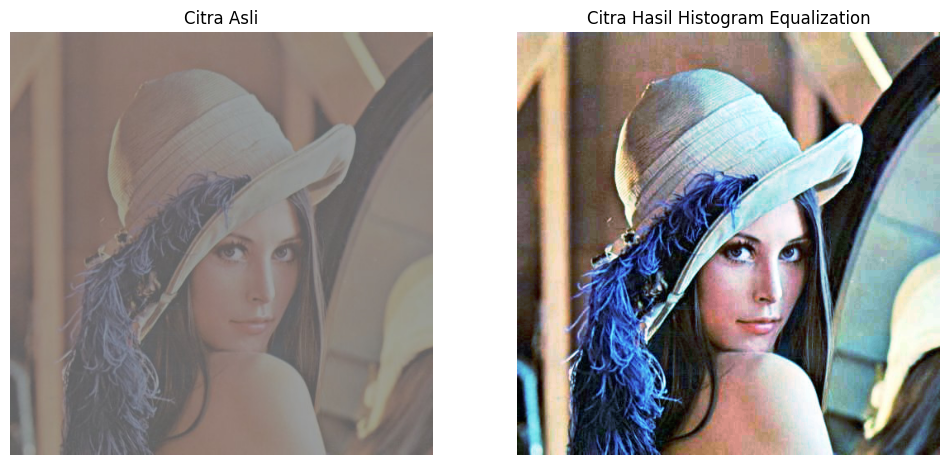

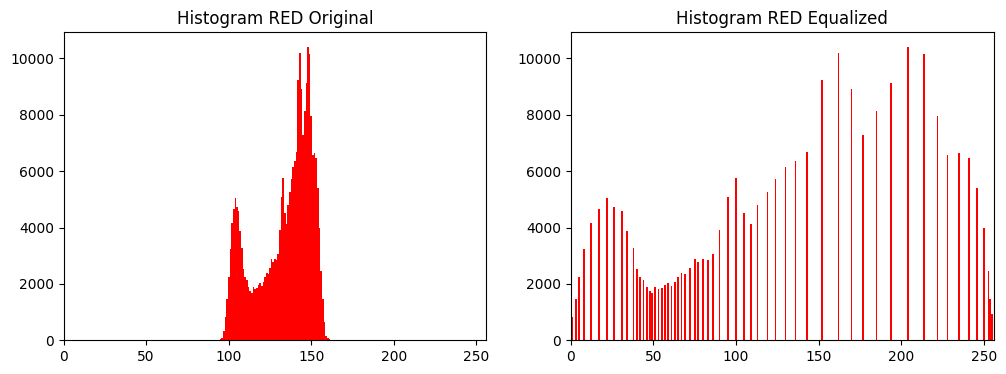

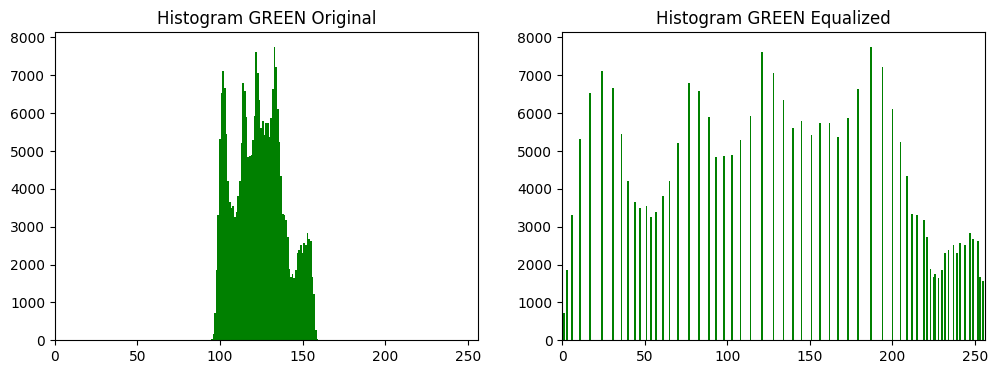

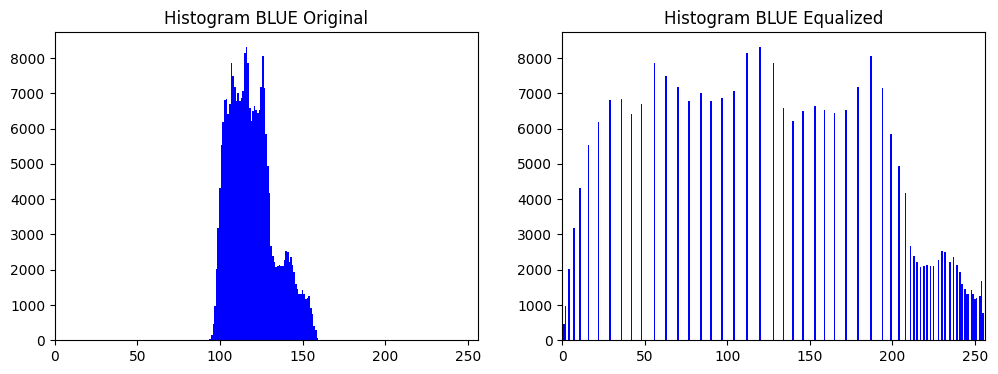

In [36]:
lenalc = cv.cvtColor(cv.imread('/content/drive/MyDrive/PCVK/lena_lc.jpg'), cv.COLOR_BGR2RGB)

r, g, b = lenalc[:,:,0], lenalc[:,:,1], lenalc[:,:,2]

histr, binsr = np.histogram(r.flatten(), 256, [0,256])
histg, binsg = np.histogram(g.flatten(), 256, [0,256])
histb, binsb = np.histogram(b.flatten(), 256, [0,256])

def manual_hist_equalization(channel):
    # 2. Hitung histogram (256 bin)
    hist, bins = np.histogram(channel.flatten(), 256, [0,256])

    # 3. Hitung CDF (kumulatif)
    cdf = hist.cumsum()

    # 4. Normalisasi CDF ke rentang 0-255
    cdf_normalized = ((cdf - cdf.min()) * 255) / (cdf.max() - cdf.min())
    cdf_normalized = cdf_normalized.astype('uint8')

    # 5. Mapping nilai lama ke nilai baru
    img_eq = cdf_normalized[channel]

    return img_eq, hist, cdf_normalized

# Proses equalization masing-masing channel
r_eq = cv.equalizeHist(r)
g_eq = cv.equalizeHist(g)
b_eq = cv.equalizeHist(b)

# Gabungkan kembali ke RGB
img_eq = cv.merge((r_eq, g_eq, b_eq))

# Tampilkan citra sebelum & sesudah
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(lenalc)
plt.title("Citra Asli")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(img_eq)
plt.title("Citra Hasil Histogram Equalization")
plt.axis('off')
plt.show()

# Tampilkan histogram sebelum dan sesudah
def plot_histograms(original_channel, equalized_channel, color):
    hist_orig, _ = np.histogram(original_channel.flatten(), 256, [0,256])
    hist_eq, _ = np.histogram(equalized_channel.flatten(), 256, [0,256])
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.bar(range(256), hist_orig, color=color, width=1)
    plt.title(f'Histogram {color.upper()} Original')
    plt.xlim([0,256])
    plt.subplot(1,2,2)
    plt.bar(range(256), hist_eq, color=color, width=1)
    plt.title(f'Histogram {color.upper()} Equalized')
    plt.xlim([0,256])
    plt.show()

# Plot histogram tiap channel sebelum & sesudah
plot_histograms(r, r_eq, 'red')
plot_histograms(g, g_eq, 'green')
plot_histograms(b, b_eq, 'blue')

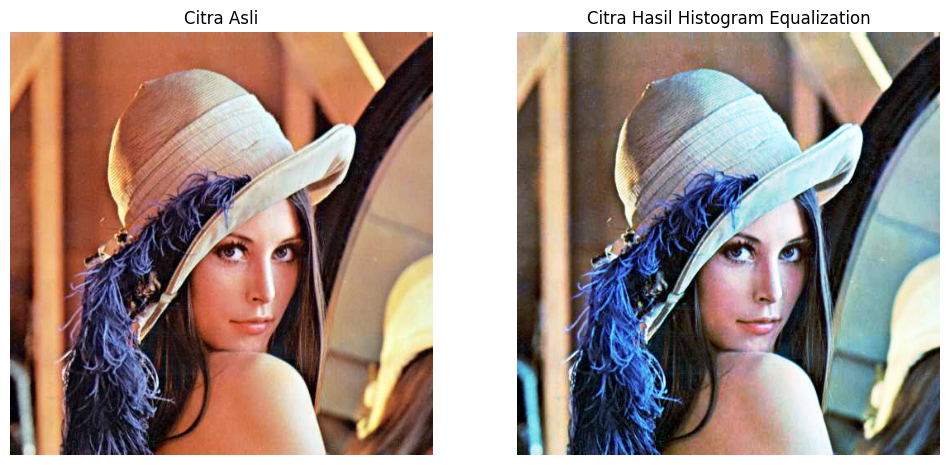

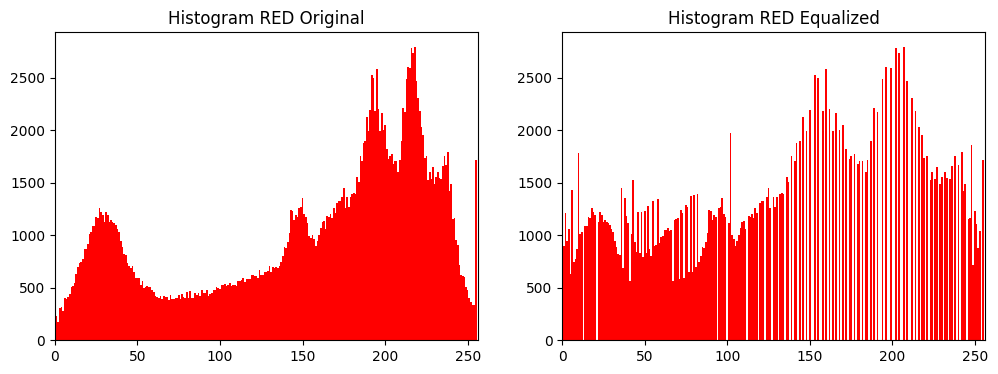

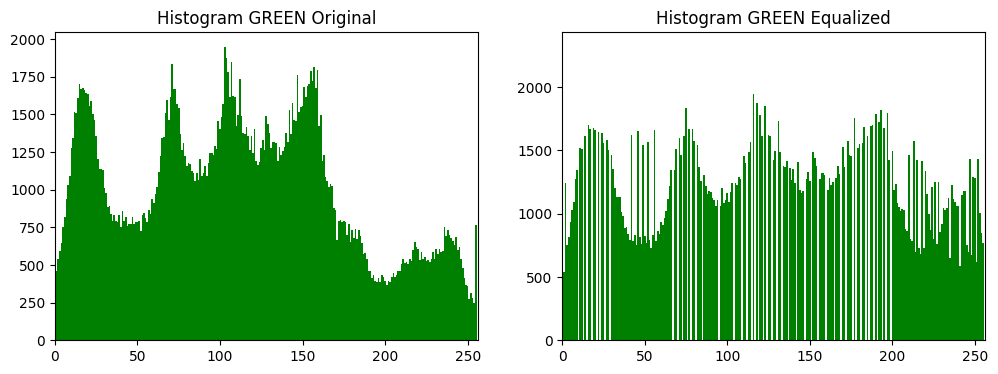

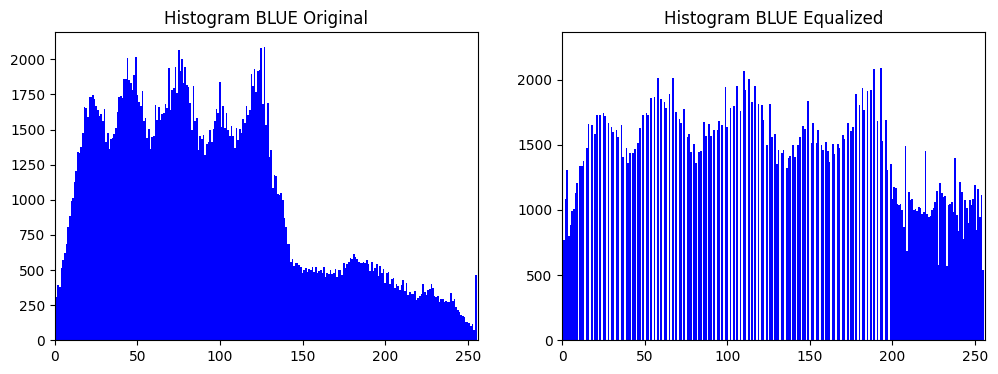

In [39]:
lenaori = cv.cvtColor(cv.imread('/content/drive/MyDrive/PCVK/lena.jpg'), cv.COLOR_BGR2RGB)

r, g, b = lenaori[:,:,0], lenaori[:,:,1], lenaori[:,:,2]

histr, binsr = np.histogram(r.flatten(), 256, [0,256])
histg, binsg = np.histogram(g.flatten(), 256, [0,256])
histb, binsb = np.histogram(b.flatten(), 256, [0,256])

def manual_hist_equalization(channel):
    # 2. Hitung histogram (256 bin)
    hist, bins = np.histogram(channel.flatten(), 256, [0,256])

    # 3. Hitung CDF (kumulatif)
    cdf = hist.cumsum()

    # 4. Normalisasi CDF ke rentang 0-255
    cdf_normalized = ((cdf - cdf.min()) * 255) / (cdf.max() - cdf.min())
    cdf_normalized = cdf_normalized.astype('uint8')

    # 5. Mapping nilai lama ke nilai baru
    img_eq = cdf_normalized[channel]

    return img_eq, hist, cdf_normalized

# Proses equalization masing-masing channel
r_eq = cv.equalizeHist(r)
g_eq = cv.equalizeHist(g)
b_eq = cv.equalizeHist(b)

# Gabungkan kembali ke RGB
img_eq = cv.merge((r_eq, g_eq, b_eq))

# Tampilkan citra sebelum & sesudah
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(lenaori)
plt.title("Citra Asli")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(img_eq)
plt.title("Citra Hasil Histogram Equalization")
plt.axis('off')
plt.show()

# Tampilkan histogram sebelum dan sesudah
def plot_histograms(original_channel, equalized_channel, color):
    hist_orig, _ = np.histogram(original_channel.flatten(), 256, [0,256])
    hist_eq, _ = np.histogram(equalized_channel.flatten(), 256, [0,256])
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.bar(range(256), hist_orig, color=color, width=1)
    plt.title(f'Histogram {color.upper()} Original')
    plt.xlim([0,256])
    plt.subplot(1,2,2)
    plt.bar(range(256), hist_eq, color=color, width=1)
    plt.title(f'Histogram {color.upper()} Equalized')
    plt.xlim([0,256])
    plt.show()

# Plot histogram tiap channel sebelum & sesudah
plot_histograms(r, r_eq, 'red')
plot_histograms(g, g_eq, 'green')
plot_histograms(b, b_eq, 'blue')


In [40]:
from math import log10, sqrt


def PSNR(ori, kw):
    mse = np.mean((ori - kw) ** 2)
    if mse == 0:
        return 100
    max_piksel = 255.0
    psnr = 20 * log10(max_piksel / sqrt(mse))
    return psnr

nilai_pnsr = PSNR(lenaori, img_eq)

print(f'Hasil hitung nilai PSNR antara citra asli dan citra hasil equalization', nilai_pnsr)


Hasil hitung nilai PSNR antara citra asli dan citra hasil equalization 28.460093386445386


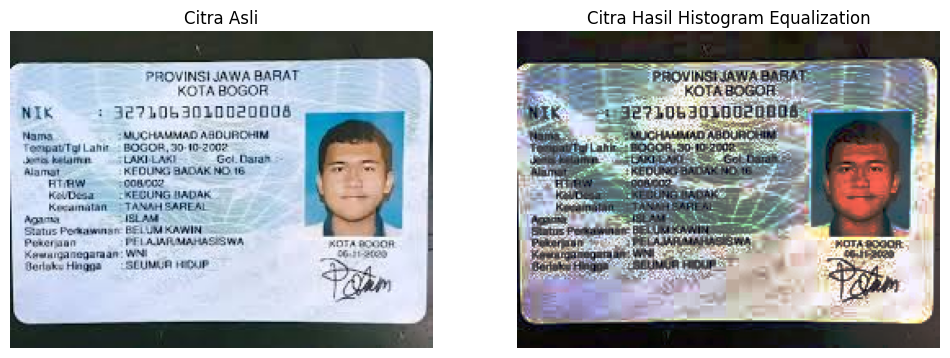

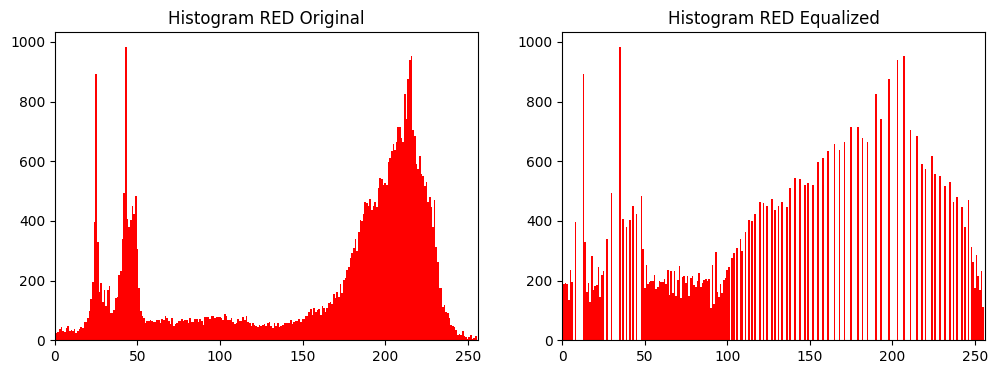

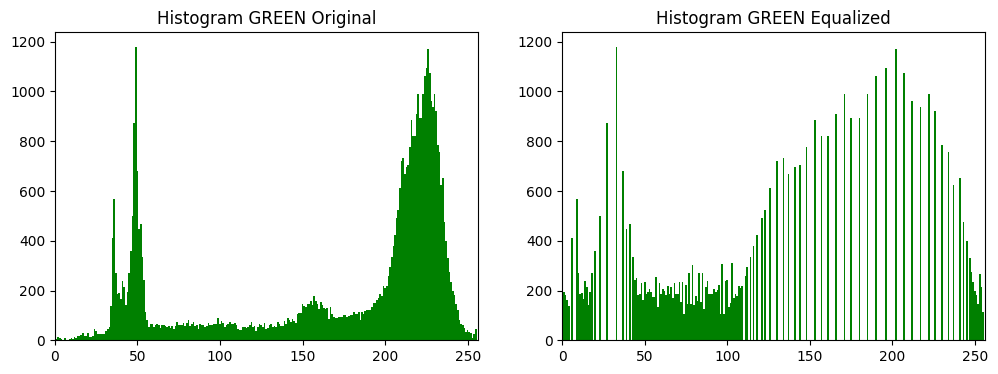

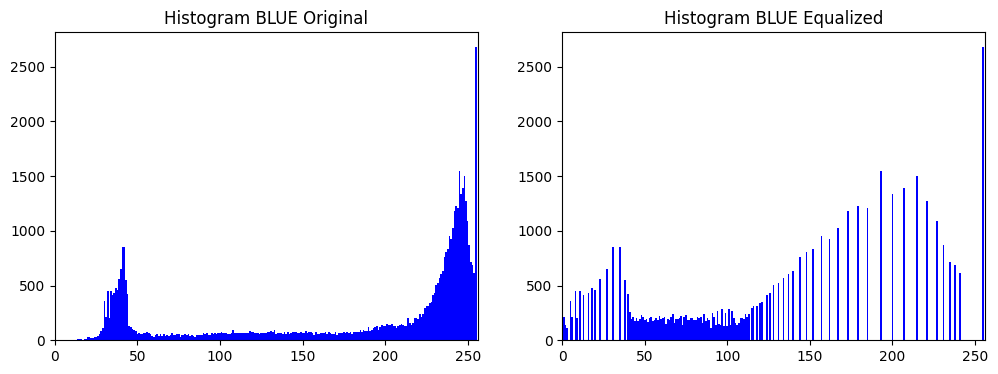

In [41]:
ktm = cv.cvtColor(cv.imread('/content/drive/MyDrive/PCVK/images.jpe   g'), cv.COLOR_BGR2RGB)

r, g, b = ktm[:,:,0], ktm[:,:,1], ktm[:,:,2]

histr, binsr = np.histogram(r.flatten(), 256, [0,256])
histg, binsg = np.histogram(g.flatten(), 256, [0,256])
histb, binsb = np.histogram(b.flatten(), 256, [0,256])

def manual_hist_equalization(channel):
    # 2. Hitung histogram (256 bin)
    hist, bins = np.histogram(channel.flatten(), 256, [0,256])

    # 3. Hitung CDF (kumulatif)
    cdf = hist.cumsum()

    # 4. Normalisasi CDF ke rentang 0-255
    cdf_normalized = ((cdf - cdf.min()) * 255) / (cdf.max() - cdf.min())
    cdf_normalized = cdf_normalized.astype('uint8')

    # 5. Mapping nilai lama ke nilai baru
    img_eq = cdf_normalized[channel]

    return img_eq, hist, cdf_normalized

# Proses equalization masing-masing channel
r_eq = cv.equalizeHist(r)
g_eq = cv.equalizeHist(g)
b_eq = cv.equalizeHist(b)

# Gabungkan kembali ke RGB
img_eq = cv.merge((r_eq, g_eq, b_eq))

# Tampilkan citra sebelum & sesudah
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(ktm)
plt.title("Citra Asli")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(img_eq)
plt.title("Citra Hasil Histogram Equalization")
plt.axis('off')
plt.show()

# Tampilkan histogram sebelum dan sesudah
def plot_histograms(original_channel, equalized_channel, color):
    hist_orig, _ = np.histogram(original_channel.flatten(), 256, [0,256])
    hist_eq, _ = np.histogram(equalized_channel.flatten(), 256, [0,256])
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.bar(range(256), hist_orig, color=color, width=1)
    plt.title(f'Histogram {color.upper()} Original')
    plt.xlim([0,256])
    plt.subplot(1,2,2)
    plt.bar(range(256), hist_eq, color=color, width=1)
    plt.title(f'Histogram {color.upper()} Equalized')
    plt.xlim([0,256])
    plt.show()

# Plot histogram tiap channel sebelum & sesudah
plot_histograms(r, r_eq, 'red')
plot_histograms(g, g_eq, 'green')
plot_histograms(b, b_eq, 'blue')


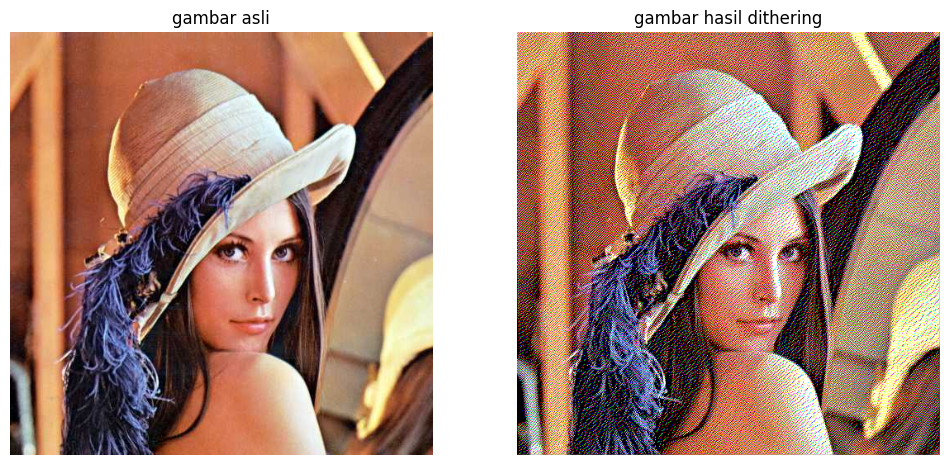

In [42]:
h,w,rgb = lenaori.shape
hasildith = lenaori.copy()
def WarnaTerdekat(pixel):
  return np.where(pixel <128, 0, 255)
def Truncate(val):
  return np.clip(val, 0, 255)

for y in range(h-1):
  for x in range(w-1):
    old_pix = hasildith[y,x].copy()
    new_pix = WarnaTerdekat(old_pix)
    hasildith[y,x] = new_pix
    error = old_pix - new_pix
    hasildith[y, x+1] = Truncate(hasildith[y, x+1] + (0.5)*error)

    hasildith[y+1, x] = Truncate(hasildith[y+1, x] + (0.5)*error)

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title('gambar asli')
plt.imshow(lenaori)
plt.axis('off')

plt.subplot(1,2,2)
plt.title('gambar hasil dithering')
plt.imshow(hasildith)
plt.axis('off')
plt.show()

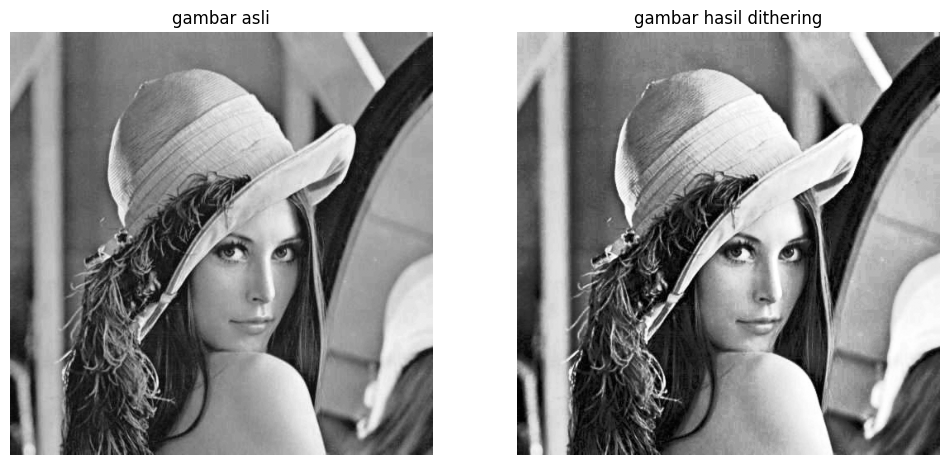

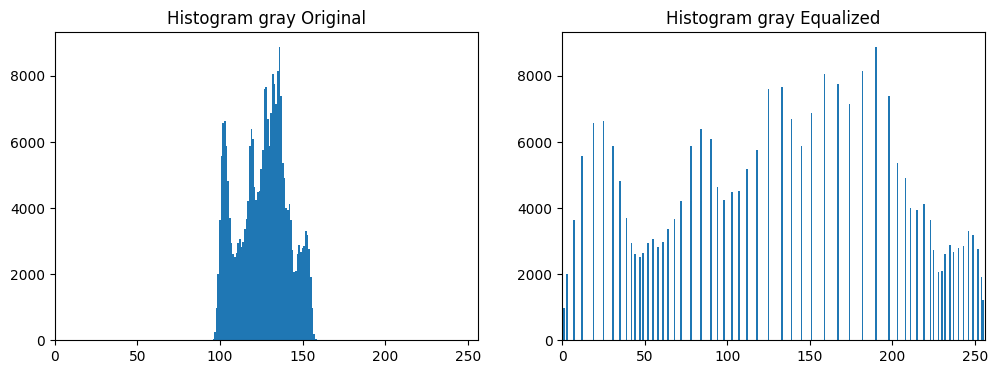

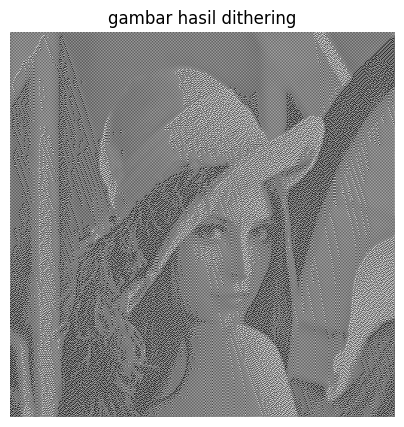

In [43]:
lenalcgrey = lenalc.copy()
lenalcgrey = cv.cvtColor(lenalcgrey, cv.COLOR_RGB2GRAY)
lenalcgreydithFNS = lenalcgrey.copy()

lenalcgrey.shape

lenalcgrey_eq = cv.equalizeHist(lenalcgrey)


for y in range(h-1):
  for x in range(w-1):
    old_pix = lenalcgreydithFNS[y,x].copy()
    new_pix = WarnaTerdekat(old_pix)
    lenalcgreydithFNS[y,x] = new_pix

    error = old_pix - new_pix
    lenalcgreydithFNS[y+1, x] = Truncate(lenalcgreydithFNS[y+1, x] + (7/16)*error)
    lenalcgreydithFNS[y-1, x+1] = Truncate(lenalcgreydithFNS[y-1, x+1] + (3/16)*error)
    lenalcgreydithFNS[y, x+1] = Truncate(lenalcgreydithFNS[y, x+1] + (5/16)*error)
    lenalcgreydithFNS[y+1, x+1] = Truncate(lenalcgreydithFNS[y+1, x+1] + (1/16)*error)

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title('gambar asli')
plt.imshow(lenalcgrey, cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.title('gambar hasil dithering')
plt.imshow(lenalcgrey_eq, cmap='gray')
plt.axis('off')
plt.show()

hist_orig, _ = np.histogram(lenalcgrey.flatten(), 256, [0,256])
hist_eq, _ = np.histogram(lenalcgrey_eq.flatten(), 256, [0,256])
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.bar(range(256), hist_orig,  width=1)
plt.title(f'Histogram gray Original')
plt.xlim([0,256])
plt.subplot(1,2,2)
plt.bar(range(256), hist_eq,  width=1)
plt.title(f'Histogram gray Equalized')
plt.xlim([0,256])
plt.show()

plt.figure(figsize=(5,5))
plt.title('gambar hasil dithering')
plt.imshow(lenalcgreydithFNS, cmap='gray')
plt.axis('off')
plt.show()